
## initialization

In [1]:
from renewable_estimator import *
import xarray as xr
import datetime

import matplotlib
import seaborn as sns
import distinctipy

%load_ext autoreload 
%autoreload 2

# Data

## physical variables

### wind

In [2]:
l = []
for year in range(1960,2024,1):
    # Read the CSV and parse time index properly
    x = pd.read_table(f'data/averaged_tables/wind100m_{year}.csv', sep=',', index_col=1).iloc[:,1:]
    # Convert index to datetime if it's not already
    x.index = pd.to_datetime(x.index)
    # Filter out leap day entries
    x = x[~x.index.strftime('%m-%d').isin(['02-29'])]
    x = x.to_xarray()
    l.append(x)

# Concatenate all years
x = xr.concat(l, dim='time')
x['onshore'] = x['DEU']
x['offshore'] = x['Baltic Sea'] + x['North Sea']

# Create the wind DataArray with proper time coordinates
wind = xr.DataArray(
    dims = ['time','region'],
    coords = dict(
        time = x.time.values,  # These are now proper datetime64 objects
        region = list(x.variables)[1:]
    )
)

# Populate the DataArray with data
for region in wind.region.values:
    wind.loc[:,region] = x[region].values

### radiation

In [3]:
l = []
for year in range(1960,2024,1):
    # Read the CSV and parse time index properly
    x = pd.read_table(f'data/averaged_tables/SSRD_{year}.csv', sep=',', index_col=1).iloc[:,1:]
    # Convert index to datetime if it's not already
    x.index = pd.to_datetime(x.index)
    # Filter out leap day entries  
    x = x[~x.index.strftime('%m-%d').isin(['02-29'])]
    x = x.to_xarray()
    l.append(x)

# Concatenate all years
x = xr.concat(l, dim='time')

# Create the radiation DataArray with proper time coordinates
radiation = xr.DataArray(
    dims = ['time','region'],
    coords = dict(
        time = x.time.values,  # These are now proper datetime64 objects
        region = list(x.variables)[1:]
    )
)

# Populate the DataArray with data
for region in radiation.region.values:
    radiation.loc[:,region] = x[region].values

## observed capacity factors

In [4]:
# Data import
df = pd.read_csv("Daten/df_merge3.csv", thousands=' ', sep=',', low_memory=False, header=0, usecols=list(range(27))+[71,72,73])
df['time2'] = pd.to_datetime(df['time2'], format='%Y-%m-%d %H:%M:%S')
df.columns = ['steps', 'time', 'year', 'month', 'year-month', 'Wind_onshore5',
       'Wind_offshore6', 'Solar7', 'Step', 'Time', 'Nuclear',
       'Hydro_Run-of-River', 'Biomass', 'Fossil_brown_coal_/_lignite',
       'Fossil_hard_coal', 'Fossil_oil', 'Fossil_coal-derived_gas',
       'Fossil_gas', 'Geothermal', 'Hydro_water_reservoir',
       'Hydro_pumped_storage', 'Others', 'Waste', 'Wind_offshore',
       'Wind_onshore', 'Solar', 'Load', 'cf_pv', 'cf_wion', 'cf_wiof']
df = df[['-02-29' not in str(t) for t in df.time.values]]

## installed capacity

In [5]:
bl_dict = {
    'Brandenburg' : 'DE.BR',
    'Berlin' : 'DE.BE',
    'Baden-Württemberg' : 'DE.BW',
    'Bayern' : 'DE.BY',
    'Bremen' : 'DE.HB',
    'Hessen' : 'DE.HE',
    'Hamburg' : 'DE.HH',
    'Mecklenburg-Vorpommern' : 'DE.MV',
    'Niedersachsen' : 'DE.NI',
    'Nordrhein-Westfalen' : 'DE.NW',
    'Rheinland-Pfalz' : 'DE.RP',
    'Schleswig-Holstein' : 'DE.SH',
    'Saarland' : 'DE.SL',
    'Sachsen' : 'DE.SN',
    'Sachsen-Anhalt' : 'DE.ST',
    'Thüringen' : 'DE.TH',
    'Baltic Sea' : 'Baltic Sea',
    'North Sea' : 'North Sea',
    'alles' : 'alles',
    'Deutschland' : 'alles'    
}

## cap past

### cap wind onshore

In [6]:
cap_wion_past = pd.read_csv("data/Data power capacity generation v2/cap_wion_reg_2000-2024.csv", sep=',', header=3, index_col=0)
cap_wion_past = cap_wion_past.T
cap_wion_past.columns = [bl_dict[bl_long] for bl_long in cap_wion_past.columns]
cap_wion_past.index = cap_wion_past.index.astype(int)
cap_wion_past = cap_wion_past.iloc[:,:-1]
cap_wion_past = cap_wion_past.map(lambda x: x.replace('\u2009', '') if isinstance(x, str) else x)


### cap pv

In [7]:
cap_pv_past = pd.read_csv("data/Data power capacity generation v2/cap_pv_reg_2001-2024.csv", sep=',', header=3, index_col=0)
cap_pv_past = cap_pv_past.T
cap_pv_past.columns = [bl_dict[bl_long] for bl_long in cap_pv_past.columns]
cap_pv_past.index = cap_pv_past.index.astype(int)
cap_pv_past = cap_pv_past.iloc[:,:-1]
cap_pv_past = cap_pv_past.map(lambda x: float(x.replace('\u2009', '').replace('-','-9999')) if isinstance(x, str) else x)
cap_pv_past[cap_pv_past == -9999] = np.nan

### cap wind offshore

In [8]:
cap_wioff_past = pd.read_csv("data/Data power capacity generation v2/cap_wioff_reg_2015-2024.csv", 
                           sep=',', header=1, index_col=0)
cap_wioff_past.columns = ['North Sea', 'Baltic Sea', 'Offshore']
cap_wioff_past = cap_wioff_past.iloc[:,:-1]
cap_wioff_past = cap_wioff_past.map(lambda x: x.replace('\u2009', '') if isinstance(x, str) else x)


## cap future

In [9]:
cap_future = pd.read_csv("data/Data power capacity generation v2/cap_ger_2030-2045-2050_v3.csv", 
                           sep=',', header=19, index_col=1)
cap_future.head()

,NAME,cap_wion_ger2030-policy,cap_wioff_ger2030-policy,cap_pv_ger2030-policy,cap_wion_ger2030-decarb,cap_wioff_ger2030-decarb,cap_pv_ger2030-decarb,time2040,cap_wion_ger2040-policy,cap_wioff_ger2040-policy,...,cap_wion_ger2040-decarb,cap_wioff_ger2040-decarb,cap_pv_ger2040-decarb,time2050,cap_wion_ger2050-policy,cap_wioff_ger2050-policy,cap_pv_ger2050-policy,cap_wion_ger2050-decarb,cap_wioff_ger2050-decarb,cap_pv_ger2050-decarb
time2030,,,,,,,,,,,,,,,,,,,,,
01.01.2030 00:00,1,107.67,27.18,195.29,113.47,29.3,235.0,01.01.2040 00:00,159.45,52.25,...,157.21,65.0,464.65,01.01.2050 00:00,165.45,78.17,400.0,162.79,63.86,471.62
01.01.2030 01:00,2,107.67,27.18,195.29,113.47,29.3,235.0,01.01.2040 01:00,159.45,52.25,...,157.21,65.0,464.65,01.01.2050 01:00,165.45,78.17,400.0,162.79,63.86,471.62
01.01.2030 02:00,3,107.67,27.18,195.29,113.47,29.3,235.0,01.01.2040 02:00,159.45,52.25,...,157.21,65.0,464.65,01.01.2050 02:00,165.45,78.17,400.0,162.79,63.86,471.62
01.01.2030 03:00,4,107.67,27.18,195.29,113.47,29.3,235.0,01.01.2040 03:00,159.45,52.25,...,157.21,65.0,464.65,01.01.2050 03:00,165.45,78.17,400.0,162.79,63.86,471.62
01.01.2030 04:00,5,107.67,27.18,195.29,113.47,29.3,235.0,01.01.2040 04:00,159.45,52.25,...,157.21,65.0,464.65,01.01.2050 04:00,165.45,78.17,400.0,162.79,63.86,471.62


# training

In [25]:
from estimator_wind.wind_sigmoid_BL import wind_sigmoid_on_BL, wind_sigmoid_off_BL
from estimator_pv.pv_linear import pv_linear_BL, pv_linear_DEU
from estimator_wind.wind_sigmoid_DEU import wind_sigmoid_on_DEU, wind_sigmoid_off_DEU

In [26]:
training_years = [2019,2021,2023]

In [27]:
estimator_pv = pv_linear_BL(
    radiation=radiation, 
    cf=df.loc[:, ['time','year','cf_pv']],
    cap = cap_pv_past, 
    training_years=training_years
    )

estimator_wind_on = wind_sigmoid_on_BL(
    wind,
    df.loc[:, ['time','year','cf_wion']],
    cap = cap_wion_past,
    training_years = training_years
    )

estimator_wind_off = wind_sigmoid_off_BL(
    wind,
    df.loc[:, ['time','year','cf_wiof']],
    cap = cap_wioff_past,
    training_years = training_years
    )

In [28]:
rn = renewable(
    estimator_wind_on = estimator_wind_on,
    estimator_wind_off = estimator_wind_off,
    estimator_pv = estimator_pv,
    cap_wioff_ratio = cap_wioff_past.loc[2020] / cap_wioff_past.loc[2020].values.sum(),
    cap_wion_ratio = cap_wion_past.loc[2020] / cap_wion_past.loc[2020].values.sum(),
    cap_pv_ratio = cap_pv_past.loc[2020] / cap_pv_past.loc[2020].values.sum(),
    cap_future = cap_future,
)

# Demand and flexibility data

In [14]:
demand = pd.read_csv('data/Data power capacity generation v2/dem_el_2030-2050_v3.csv', header=19)
demand.head()

,NAME,time2030,Electricity demand 2030ENTSO-E policy,Electricity demand 2030policy,Electricity demand 2030decarb,time2040,Electricity demand 2040ENTSO-E policy,Electricity demand 2040policy,Electricity demand 2040decarb,time2050,Electricity demand 2050ENTSO-E policy,Electricity demand 2050policy,Electricity demand 2050decarb
0,1,01.01.2030 00:00,81.791,68.7910,79.3573,01.01.2040 00:00,94.829,92.6320,134.4979,01.01.2050 00:00,105.124,117.4686,144.5661
1,2,01.01.2030 01:00,78.140,65.7203,75.8150,01.01.2040 01:00,90.916,88.8097,128.9480,01.01.2050 01:00,100.962,112.8179,138.8425
2,3,01.01.2030 02:00,75.516,63.5134,73.2690,01.01.2040 02:00,87.630,85.5998,124.2874,01.01.2050 02:00,96.672,108.0241,132.9429
3,4,01.01.2030 03:00,73.772,62.0466,71.5769,01.01.2040 03:00,85.326,83.3492,121.0196,01.01.2050 03:00,93.496,104.4752,128.5753
4,5,01.01.2030 04:00,72.779,61.2114,70.6135,01.01.2040 04:00,83.947,82.0021,119.0637,01.01.2050 04:00,91.510,102.2559,125.8442


In [15]:
table_csv = pd.read_table('data/Data power capacity generation v2/cap_flex_2025-2050_v2.csv',
                                      sep=',', index_col=0, header=2)
table_csv.head()

,Category,Flexibility option name,2020_policy,2030_policy,2040_policy,2050_policy,Source_policy,_,2020_decarb,2030_decarb,2040_decarb,2050_decarb,Source_decarb,
Data quality,,,,,,,,,,,,,,
Good,Generation,Gas+H2_GW,30.0,42.60,47.56,52.53,cf. BNetzA NEP 2025 Szenariorahmen Szenario B,,29.47,39.77,63.99,87.92,"Ariadne 2025, Scenario KN2045_Mix",
Good,Generation,Hydro_GW,4.6,4.60,4.60,4.60,cf. BNetzA NEP 2025 Szenariorahmen Szenario B,,3.35,3.35,3.35,3.35,"Ariadne 2025, Scenario KN2045_Mix",
Good,Generation,Biomass_GW,9.1,7.05,5.65,4.25,cf. BNetzA NEP 2025 Szenariorahmen Szenario B,,12.86,10.81,5.39,0.79,"Ariadne 2025, Scenario KN2045_Mix",
Good,Storage,Hydro_storage_GW,9.7,10.70,11.20,11.70,cf. BNetzA NEP 2025 Szenariorahmen Szenario B,,7.53,7.53,7.53,7.53,"Ariadne 2025, Scenario KN2045_Mix",
Good,Storage,Hydro_storage_GWh,39.0,43.02,45.03,47.04,cf. BNetzA NEP 2025 Szenariorahmen Szenario B,,39.87,39.87,39.87,39.87,"Ariadne 2025, Scenario KN2045_Mix",


In [16]:
flexibility = xr.DataArray(
    name = 'flexibility',
    dims = ['scenario','year','category'],
    coords = dict(
        scenario = ['policy', 'decarb'],
        year = np.arange(2020,2055,10,'int'),
        category = [f.replace('_',' ') for f in table_csv['Flexibility option name'].values]
    )
)
for col in table_csv.columns[2:-1]:
    if 'Source' not in col and col != ' _':
        year = int(col.split('_')[0])
        scenario = col.split('_')[1]
        flexibility.loc[scenario,year,:] = table_csv[col].values

# plotting
## plotting functions

In [190]:
def create_dummy_X(period_lengths):
    # create output array to store the aggregated data
    dummy_X = xr.DataArray(
        dims=['period_length', 'weather_year', 'start_time'], 
        coords=dict(
            # all hours of the year
            start_time=range(365*24), 
            # all available weather years
            weather_year=range(1960,2023,1),
            # periods over which to aggregate
            period_length=period_lengths
        )
    )
    return dummy_X

In [191]:
def get_rl(infrastructure_scenario, infrastructure_year, period_lengths):
    load = demand[f'Electricity demand {infrastructure_year}{infrastructure_scenario}']
    load = np.append(load[:8760], load[:8760])

    # create output array to store the aggregated data
    X = create_dummy_X(period_lengths)

    # go through weather years
    for weather_year in X.weather_year.values:
        re = rn.estimate_renewable_energy_generation(weather_year=weather_year, infrastructure_scenario=infrastructure_scenario, infrastructure_year=infrastructure_year) 
        re_next = rn.estimate_renewable_energy_generation(
            weather_year=weather_year + 1, infrastructure_scenario=infrastructure_scenario, infrastructure_year=infrastructure_year)
        re = np.append(re[:8760], re_next[:8760])
        rl = xr.DataArray(load - re, dims=["time"], coords=dict(time=np.arange(0,24*365*2,1,'int')))
        for period_length in X.period_length.values:
            # store average or aggregated time windows
            X.loc[period_length,weather_year] = rl.rolling(time=period_length).mean()[period_length-1:][:365*24].values
    return X

In [192]:
def get_re(infrastructure_scenario, infrastructure_year, period_lengths):
    # create output array to store the aggregated data
    X = create_dummy_X(period_lengths)

    # go through weather years
    for weather_year in X.weather_year.values:
        re = rn.estimate_renewable_energy_generation(
            weather_year=weather_year, 
            infrastructure_scenario=infrastructure_scenario, 
            infrastructure_year=infrastructure_year
            ) 
        re_next = rn.estimate_renewable_energy_generation(
            weather_year=weather_year + 1, 
            infrastructure_scenario=infrastructure_scenario, 
            infrastructure_year=infrastructure_year
            )
        re = np.append(re[:8760], re_next[:8760])
        rl = xr.DataArray(re, dims=["time"], coords=dict(time=np.arange(0,24*365*2,1,'int')))
        for period_length in X.period_length.values:
            # store average or aggregated time windows
            X.loc[period_length,weather_year] = rl.rolling(time=period_length).mean()[period_length-1:][:365*24].values
    return X

#### fish

In [193]:
def plot_fish(ax, X, color='r', plot_year_stripes=True):
    # identify extremes for all period_length length and weather years
    mini = X.min('start_time')
    maxi = X.max('start_time')
    meani = X.median('start_time')

    # do for minimums and maximums
    for stat_name, statistic in zip(['min','max','mean'],[mini,maxi,meani]):
        x_ = []
        y_ = []
        # got through period_lengths
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):

            if stat_name != 'mean':
                # fill between lowest and highest weather year
                ax.fill_between(
                    # x values
                    [start_x,period_length], 
                    # upper x values
                    [statistic.loc[period_length].min('weather_year')] * 2, 
                    # upper y values
                    [statistic.loc[period_length].max('weather_year')] * 2, 
                    facecolor=color, edgecolor='none', alpha=0.4)

                # draw one line for each weather year
                if plot_year_stripes:
                    for weather_year in X.weather_year.values:
                        ax.scatter(np.mean([start_x,period_length]), [statistic.loc[period_length, weather_year]], color=color, marker=(2, 0, 90), s=50)  
                    zz = statistic.loc[period_length]
                    if stat_name == 'min':
                        t = ax.annotate(zz.weather_year.values[np.argmin(zz.values)], xy=(np.mean([start_x,period_length]), zz.values[np.argmin(zz.values)]), ha='center', va='top', fontsize=8)
                    if stat_name == 'max':
                        t = ax.annotate(zz.weather_year.values[np.argmax(zz.values)], xy=(np.mean([start_x,period_length]), zz.values[np.argmax(zz.values)]), ha='center', va='bottom', fontsize=8)
                    
            y_ += [statistic.loc[period_length].mean('weather_year')] * 2
            x_ += [start_x,period_length]

        # indicate average
        ax.plot(x_, y_, color=color, zorder=10)

    mini, maxi = X.min(), X.max()
    add = (maxi-mini) / 10
    ax.set_ylim(mini-add,maxi+add)
    ax.axhline(0, color='k')
    return ax



#### load

In [194]:
def plot_load(ax, infrastructure_scenario, infrastructure_year, period_lengths, color='orange'):
    load = demand[f'Electricity demand {infrastructure_year}{infrastructure_scenario}']
    load = np.append(load[:8760], load[:8760])

    # create output array to store the aggregated data
    X = create_dummy_X(period_lengths)

    # go through weather years
    for weather_year in X.weather_year.values:
        load = xr.DataArray(load, dims=["time"], coords=dict(time=np.arange(0,24*365*2,1,'int')))
        for period_length in X.period_length.values:
            # store average or aggregated time windows
            X.loc[period_length,weather_year] = load.rolling(time=period_length).mean()[period_length-1:][:365*24].values

    x_ = []
    y_ = []
    # got through period_lengths
    for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):

        # fill between lowest and highest weather year
        ax.fill_between(
            # x values
            [start_x,period_length], 
            # upper x values
            [X.loc[period_length].min()] * 2, 
            # upper y values
            [X.loc[period_length].max()] * 2, 
            facecolor=color, edgecolor='none', alpha=0.4)

        y_ += [X.loc[period_length].mean()] * 2
        x_ += [start_x,period_length]

    # indicate average
    ax.plot(x_, y_, color=color, zorder=10)
    ax.fill_between([],[],[], facecolor=color, edgecolor='none', alpha=0.4, label=infrastructure_scenario)

    return ax

In [195]:
def get_flex_power(infrastructure_scenario, infrastructure_year, period_lengths):
    if infrastructure_scenario == 'ENTSO-E policy':
        infrastructure_scenario = 'policy'
        print('using policy scenario for flexibility instead of ENTSO-E-policy (because missing)')

    flex = xr.DataArray(
        dims=['name', 'period_length'], 
        coords=dict(
            # all hours of the year
            name=flex_option_names, 
            # periods over which to aggregate
            period_length=period_lengths
        )
    )

    for flex_name in flex_option_names:
        for period in period_lengths:
            if f'{flex_name} GWh' in flexibility.category.values:
                energie = flexibility.loc[infrastructure_scenario,infrastructure_year,f'{flex_name} GWh']
            else: 
                energie = 10**10
            leistung = flexibility.loc[infrastructure_scenario,infrastructure_year,f'{flex_name} GW']
            if leistung > energie / period:
                leistung = energie / period
            flex.loc[flex_name, period] = leistung
    return flex

#### flex

In [196]:
flex_option_names = np.unique([' '.join(f.split(' ')[:-1]) for f in flexibility.category.values])
flex_option_names = [n for n in flex_option_names if 'Gas' not in n] + ['Gas+H2']
flex_option_names = ['DSM industry','Hydro storage','Battery', 'V2G', 'Hydro', 'Biomass', 'Gas+H2']

In [197]:
flex_option_colors = distinctipy.distinctipy.get_colors(len(flex_option_names)-1, pastel_factor=0.6, rng=0)
flex_option_colors += ['lightgray']

In [198]:
flex_option_colors = [
    (0.37901465856134103, 0.40073616391118655, 0.763048002513779),
    (0.4035306000311567, 0.834794204761147, 0.9905768271224837),
    (0.3988130934320259, 0.9824695665014744, 0.42978279305730477),
    (0.9062095661217789, 0.42844275514289465, 0.9802966089164015),
    (0.9913298139074157, 0.5673291022816619, 0.39314788698466774),
    'lightgray']

In [199]:
def plot_flexibility_options(ax, infrastructure_scenario, infrastructure_year, period_lengths):
    flex = get_flex_power(infrastructure_scenario,infrastructure_year, period_lengths)
    x = [0]
    for period in period_lengths:
        x += [x[-1] + period] * 2
    x = x[:-1]
    x_axis = np.array(x)
    y_low = x_axis * 0
    for flex_name, color in zip(flex_option_names, flex_option_colors):
        if f'{flex_name} GWh' in flexibility.category.values:
            y_high = np.array([[f] * 2 for f in flex.loc[flex_name].values]).flatten() + y_low
            ax.fill_between(x_axis, y_high, y_low, alpha=0.5, edgecolor='none', facecolor=color, label=flex_name)
            y_low = y_high
        if f'{flex_name} GWh' not in flexibility.category.values:
            y_high = np.array([[f] * 2 for f in flex.loc[flex_name].values]).flatten() + y_low
            ax.fill_between(x_axis, y_high, y_low, alpha=0.5, edgecolor='none', facecolor=color, label=flex_name)
            y_low = y_high
    return ax

#### prep axes

In [200]:
period_lengths = np.array([1,3,6,12,24] + [d*24 for d in [2,4,7,14,30,60,90,180,365]])
period_length_labels = np.array(['1H', '3H', '6H', '12H', '1D', '2D', '4D', '7D', '14D','1M','2M','3M','6M','1Y'])
def prepare_axes():
    fig,ax = plt.subplots()
    ax.set_xscale('log')
    ax.set_xlim(0.5,period_lengths[-1])
    ax.set_xticks(period_lengths)
    ax.set_xticklabels(period_length_labels)
    ax.set_xlabel('aggregation period [hours]')
    plt.minorticks_off()
    return ax

## examples: how to use the plotting functions

In [201]:
infrastructure_year = 2030
infrastructure_scenario = 'policy'

Text(0, 0.5, 'Renewable energy [GW]')

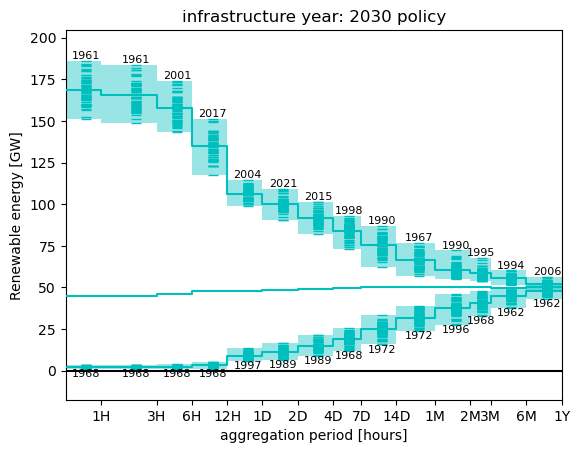

In [202]:
# plot renewable energy generation
X = get_re(infrastructure_scenario, infrastructure_year, period_lengths)
ax = prepare_axes()
ax.set_title(f"infrastructure year: {infrastructure_year} {infrastructure_scenario}")
ax = plot_fish(ax, X, color='c')
ax.set_ylabel('Renewable energy [GW]')

Text(0, 0.5, 'Demand [GW]')

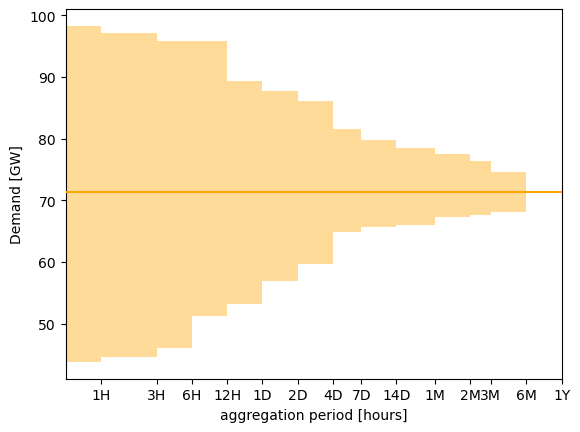

In [203]:
# plot demand
ax = prepare_axes()
ax = plot_load(ax, infrastructure_scenario, infrastructure_year, period_lengths)
ax.set_ylabel('Demand [GW]')

Text(0, 0.5, 'Renewable energy [GW]')

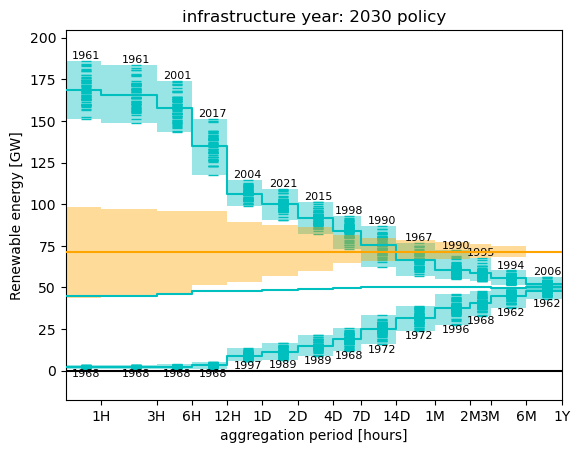

In [204]:
# plot renewable energy generation and add demand
X = get_re(infrastructure_scenario, infrastructure_year, period_lengths)
ax = prepare_axes()
ax.set_title(f"infrastructure year: {infrastructure_year} {infrastructure_scenario}")
ax = plot_fish(ax, X, color='c')
ax = plot_load(ax, infrastructure_scenario, infrastructure_year, period_lengths)
ax.set_ylabel('Renewable energy [GW]')

Text(0, 0.5, 'Residual load [GW]')

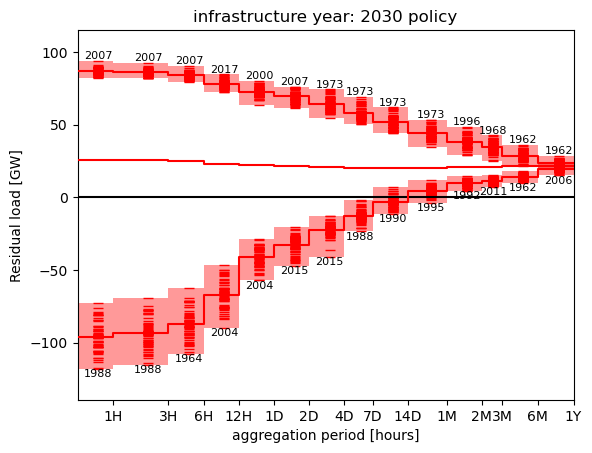

In [205]:
# plot residual load
X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)
ax = prepare_axes()
ax.set_title(f"infrastructure year: {infrastructure_year} {infrastructure_scenario}")
ax = plot_fish(ax, X)
ax.set_ylabel('Residual load [GW]')

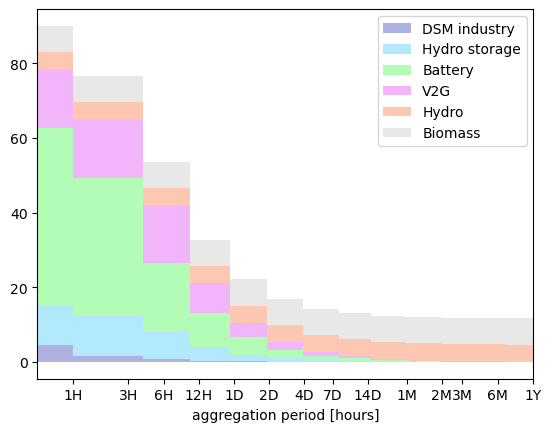

In [206]:
# plot flexibility options
ax = prepare_axes()
ax = plot_flexibility_options(ax, infrastructure_scenario, infrastructure_year, period_lengths)
ax.legend()

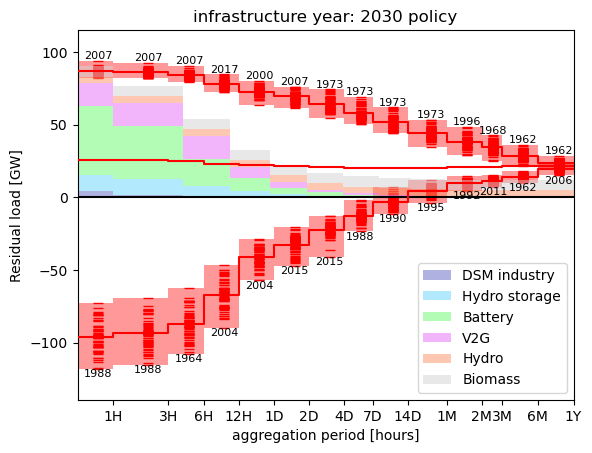

In [207]:
# plot residual load
X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)
ax = prepare_axes()
ax.set_title(f"infrastructure year: {infrastructure_year} {infrastructure_scenario}")
ax = plot_fish(ax, X)
ax.set_ylabel('Residual load [GW]')
ax = plot_flexibility_options(ax, infrastructure_scenario, infrastructure_year, period_lengths)
ax.legend()

In [208]:
print("forced stop")
raise SystemExit()

forced stop


SystemExit: 

/home/peterp/miniforge3/envs/py_gmlnet/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


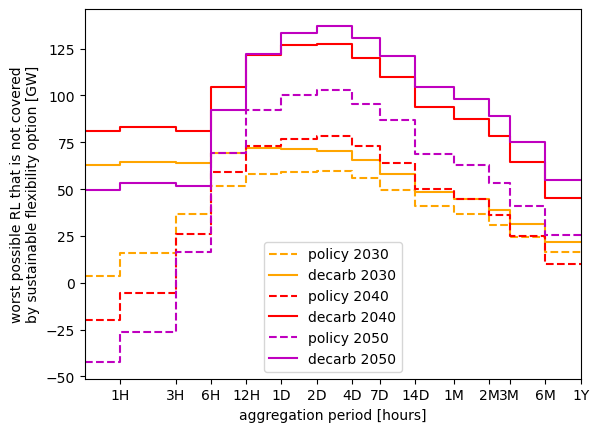

In [ ]:
ax = prepare_axes()
sustainable_flex_option_names = [f for f in flex_option_names if f != 'Gas+H2']
for infrastructure_year, color in zip([2030,2040,2050], ['orange','red','m']):
    for infrastructure_scenario, linestyle in zip(['policy', 'decarb'], ['--','-',':']):
        X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)
        flex = get_flex_power(infrastructure_scenario, infrastructure_year, period_lengths)
        y = X.max(('weather_year','start_time')) - flex.loc[sustainable_flex_option_names].sum('name')
        y = np.array([[x]*2 for x in y]).flatten()
        x_axis = [0.5] + list(np.array([[x]*2 for x in period_lengths]).flatten()[:-1])
        ax.plot(x_axis, y, color=color, linestyle=linestyle, label=f"{infrastructure_scenario} {infrastructure_year}")
ax.legend()
ax.set_ylabel('worst possible RL that is not covered\nby sustainable flexibility option [GW]')
plt.savefig(f'../plots/RL/peak_RL_per_period.png', dpi=300)


## main plots


### RL

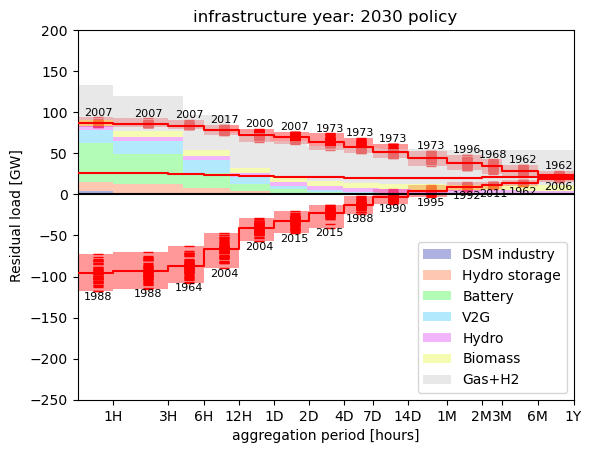

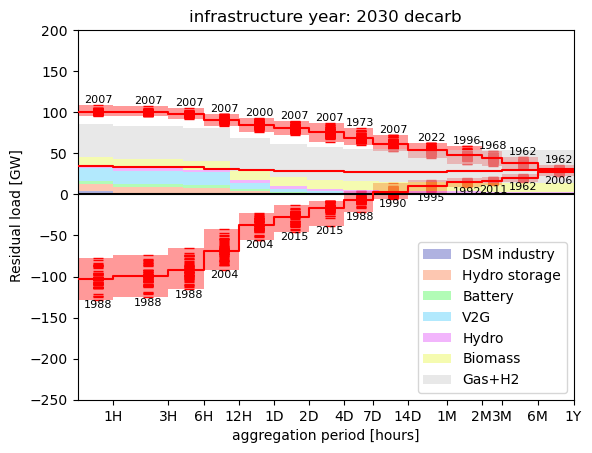

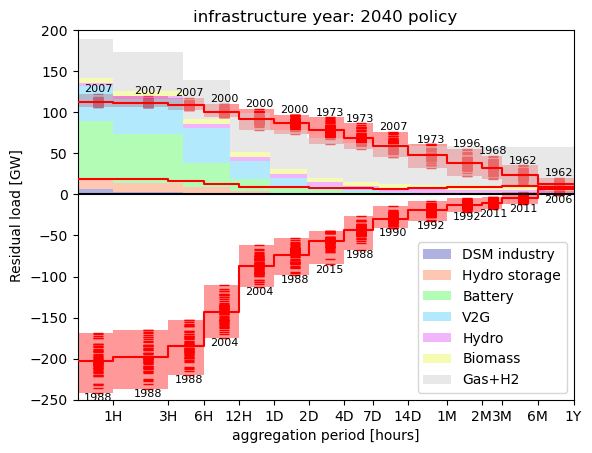

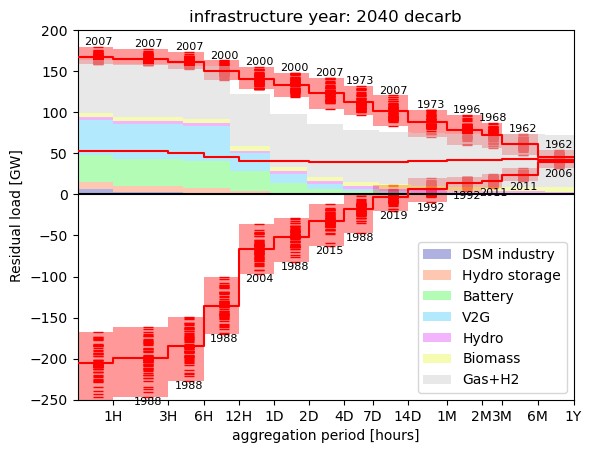

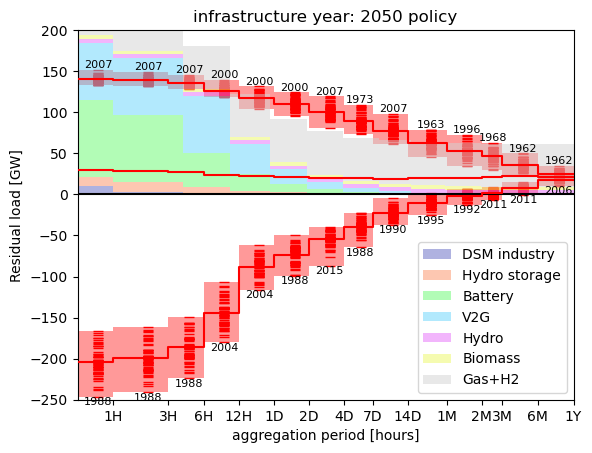

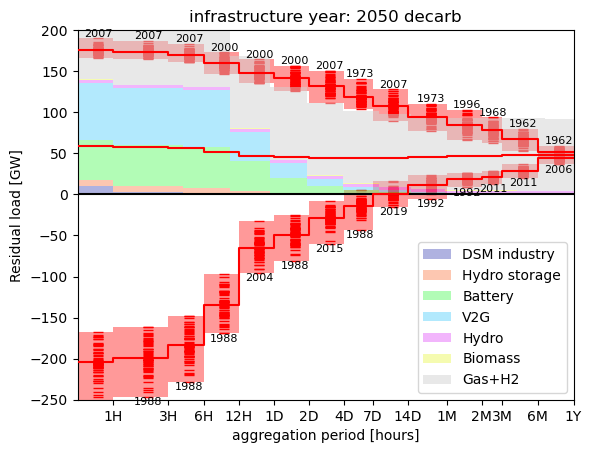

In [ ]:
for infrastructure_year in [2030,2040,2050]:
    for infrastructure_scenario in ['policy', 'decarb']:
        X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)
        ax = prepare_axes()
        ax.set_title(f"infrastructure year: {infrastructure_year} {infrastructure_scenario}")
        ax = plot_fish(ax, X, color='red')
        ax.set_ylabel('Residual load [GW]')
        ax.set_ylim(-250, 200)
        ax = plot_flexibility_options(ax, infrastructure_scenario, infrastructure_year, period_lengths)
        ax.legend(loc='lower right')
        plt.savefig(f'../plots/RL/RL_{infrastructure_scenario}_{infrastructure_year}.png', dpi=300)


#### worst years

In [ ]:
X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)

In [ ]:
import matplotlib
norm = matplotlib.colors.Normalize(vmin=0.0, vmax=len(X.weather_year.values))
cmap = matplotlib.colormaps['Reds']

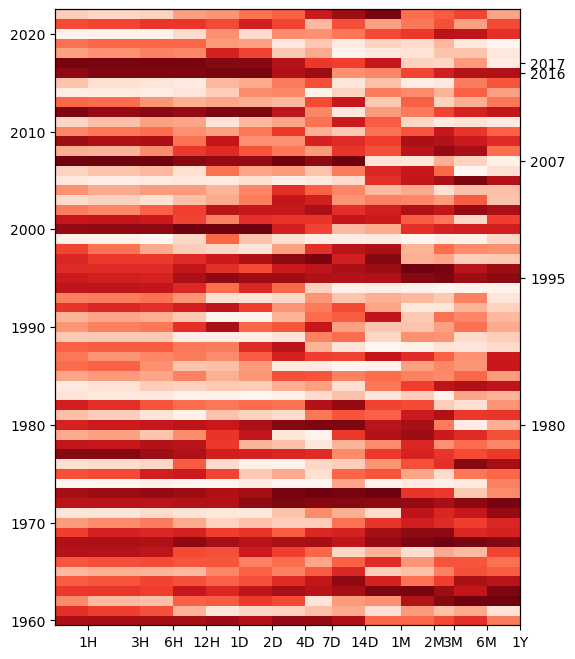

In [ ]:
fig,ax = plt.subplots(figsize=(6,8))
to_plot = X[:,:,0].squeeze().copy()
for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
    zz = X.loc[period_length].max('start_time')
    zz_sorted = zz.sortby(zz)
    for year in X.weather_year.values:
        color = cmap(norm(np.where(zz_sorted.weather_year.values==year)[0][0]))
        ax.fill_between([start_x,period_length], [year-0.5] * 2, [year+0.5] * 2, 
            facecolor=color, edgecolor='none')

ax.set_xlim(0.5,365*24)
ax.set_xscale('log')
ax.set_xticks(period_lengths)
_ = ax.set_xticklabels(period_length_labels)
_ = ax.set_ylim(1959.5, 2022.5)
ax2 = ax.twinx()
_ = ax2.set_ylim(1959.5, 2022.5)
ax2.set_yticks([2007,2016,2017,1995,1980])
plt.minorticks_off()

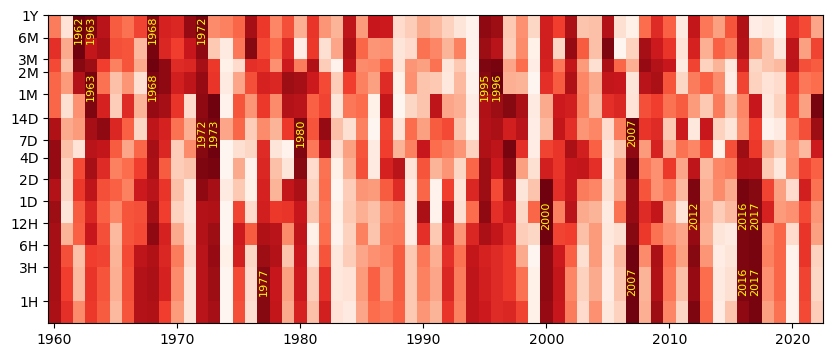

In [ ]:
fig,ax = plt.subplots(figsize=(10,4))
to_plot = X[:,:,0].squeeze().copy()
for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
    zz = X.loc[period_length].max('start_time')
    zz_sorted = zz.sortby(zz)
    for year in X.weather_year.values:
        color = cmap(norm(np.where(zz_sorted.weather_year.values==year)[0][0]))
        ax.fill_between([year-0.5, year+0.5], [start_x]*2, [period_length]*2, 
            facecolor=color, edgecolor='none')

for p in [3, 24, 24*14, 24*30*2, 24*365]:
    a = X.loc[p].max('start_time')
    for year in a[a > np.percentile(a, 95)].weather_year.values:
        ax.annotate(year, xy=(year, p), ha='center', va='top', rotation=90, color='yellow', fontsize=8)


ax.set_ylim(0.5,365*24)
ax.set_yscale('log')
ax.set_yticks(period_lengths)
_ = ax.set_yticklabels(period_length_labels)
_ = ax.set_xlim(1959.5, 2022.5)
plt.minorticks_off()

#### Seasonality

In [ ]:
def get_seasonality_of_rl(infrastructure_scenario, infrastructure_year):
    l = []
    for weather_year in range(1960,2023):
        load = demand[f'Electricity demand {infrastructure_year}{infrastructure_scenario}']
        re = rn.estimate_renewable_energy_generation(weather_year=weather_year, infrastructure_scenario=infrastructure_scenario, infrastructure_year=infrastructure_year) 
        base = datetime.datetime(weather_year, 1, 1)
        date_list = np.array([base + datetime.timedelta(hours=x) for x in range(24*366)])
        date_list = np.array([d for d in date_list if d.year == weather_year])
        date_list = np.array([d for d in date_list if (d.day == 29 and d.month == 2) == False])
        l.append(xr.DataArray(load - re, dims=["time"], coords=dict(time=date_list)))

    rl = xr.concat(l, dim='time')
    x = np.zeros([24,12])
    for month in range(1,13):
        for hour in range(24):
            x[hour,month-1] = rl[(rl.time.dt.month == month) & (rl.time.dt.hour == hour)].mean()

    return x

In [ ]:
seasonality = []
for infrastructure_scenario in ['policy', 'decarb']:
    for infrastructure_year in [2030 ,2040, 2050]:
        seasonality.append([
            infrastructure_scenario,
            infrastructure_year,
            get_seasonality_of_rl(infrastructure_scenario, infrastructure_year)
            ])

In [ ]:
import sunriset
sun_df = sunriset.to_pandas(datetime.datetime(2025,1,1), 51, 9, 1, 1)
sunrise = np.array([int(str(s).split(':')[0].split(' ')[-1]) + int(str(s).split(':')[1])/60 for s in sun_df.Sunrise])
sunset = np.array([int(str(s).split(':')[0].split(' ')[-1]) + int(str(s).split(':')[1])/60 for s in sun_df.Sunset])

cvals  = [-100, -50, 0, 50, 100]
colors = ["darkgreen", "lightgreen", "white", "red", 'k']
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

cvals  = [-100, 0, 100]
colors = ["blue", "white", "red"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap_diff = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

In [237]:
ref = seasonality[1][2]

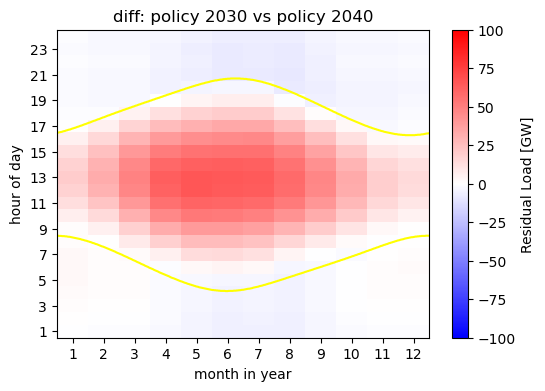

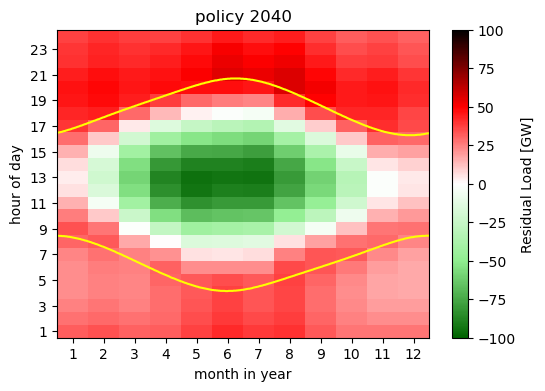

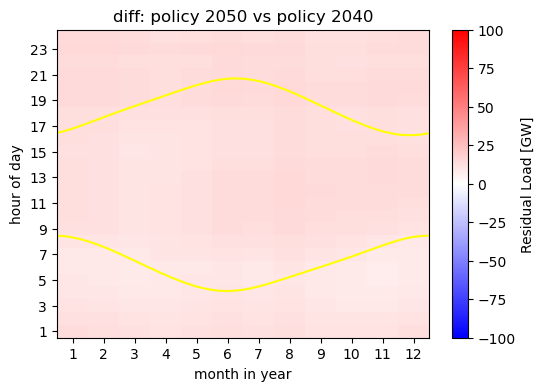

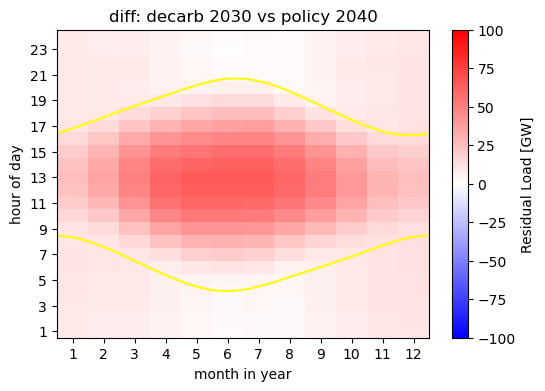

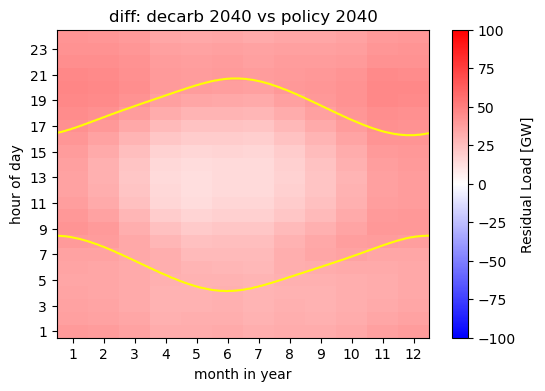

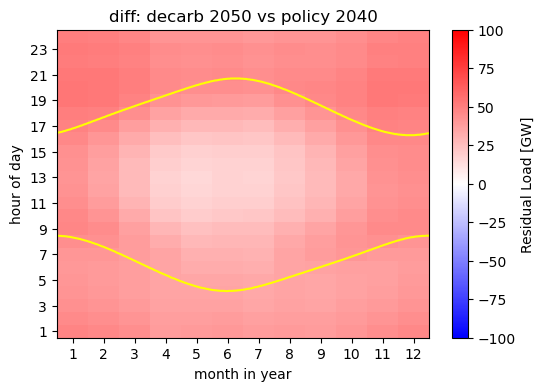

In [ ]:
for infrastructure_scenario, infrastructure_year, x in seasonality:
    fig,ax = plt.subplots(figsize=(6,4))
    if infrastructure_scenario == 'policy' and infrastructure_year == 2040:
        im = ax.pcolormesh(np.arange(0.5,13.5,1), np.arange(0.5,25,1), x, vmin=-100, vmax=100, cmap=cmap)
        ax.set_title(f"{infrastructure_scenario} {infrastructure_year}")
    else:
        im = ax.pcolormesh(np.arange(0.5,13.5,1), np.arange(0.5,25,1), x - ref, vmin=-100, vmax=100, cmap=cmap_diff)
        ax.set_title(f"diff: {infrastructure_scenario} {infrastructure_year} vs policy 2040")  
    ax.set_xticks(np.arange(1,13,1,'int'))
    ax.set_yticks(np.arange(1,25,2))
    plt.colorbar(im, label='Residual Load [GW]')

    ax.plot(np.linspace(0.5,12.5,365), sunrise, color='yellow')
    ax.plot(np.linspace(0.5,12.5,365), sunset, color='yellow')
    ax.set_ylabel('hour of day')
    ax.set_xlabel('month in year')

##### seasonality with flex option?

In [296]:
infrastructure_scenario = 'policy'
infrastructure_year = 2040
x = get_seasonality_of_rl(infrastructure_scenario, infrastructure_year)

In [300]:
def plot_seasonality_with_flex(x, max_capacity):
    for month in range(12):
        y = x[:,month].copy()
        charging_hours = np.where(y < 0)[0]
        if charging_hours.shape[0] > 0:
            charged_capacity = -y[charging_hours].sum()
            charged_capacity = np.min([charged_capacity, max_capacity])
            for h in list(np.arange(charging_hours[-1]+1, 24)) + list(np.arange(0,charging_hours[0])):
                if charged_capacity > y[h]:
                    charged_capacity -= y[h]
                    y[h] = 0
                else:
                    y[h] -= charged_capacity
                    charged_capacity = 0
                    break
                
            if charged_capacity == 0:
                y[charging_hours] = 0
            else:
                for h in charging_hours:
                    if charged_capacity > -y[h]:
                        charged_capacity -= -y[h]
                        pass
                    else:
                        y[h] -= -charged_capacity
                        charged_capacity = 0
                        break
                for h in range(h, charging_hours[-1]+1):
                    y[h] = 0


            x[:,month] = y
            
    fig,ax = plt.subplots(figsize=(6,4))
    im = ax.pcolormesh(np.arange(0.5,13.5,1), np.arange(0.5,25,1), x, vmin=-100, vmax=100, cmap=cmap)
    ax.set_title(f"{infrastructure_scenario} {infrastructure_year}")

    ax.set_xticks(np.arange(1,13,1,'int'))
    ax.set_yticks(np.arange(1,25,2))
    plt.colorbar(im, label='Residual Load [GW]')

    ax.plot(np.linspace(0.5,12.5,365), sunrise, color='yellow')
    ax.plot(np.linspace(0.5,12.5,365), sunset, color='yellow')
    ax.set_ylabel('hour of day')
    ax.set_xlabel('month in year')

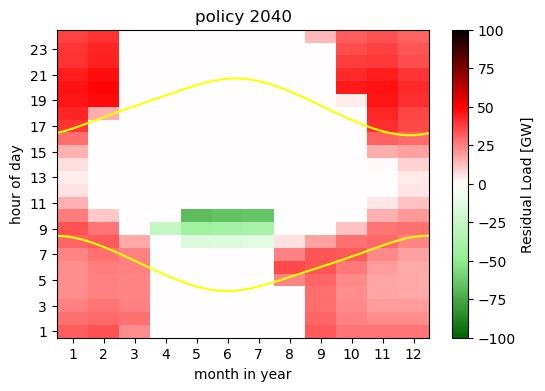

In [301]:
plot_seasonality_with_flex(x.copy(), 10*999)

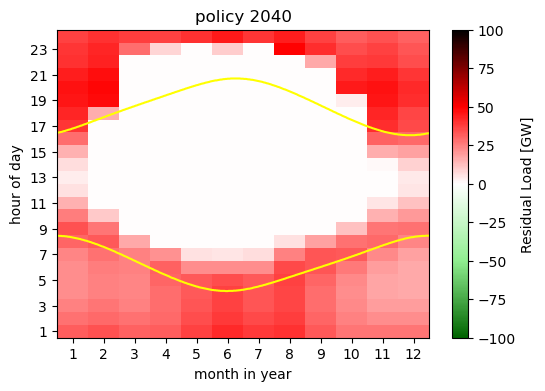

In [302]:
green_storage = flexibility.loc[infrastructure_scenario, infrastructure_year, ['Hydro storage GWh', 'Battery GWh']].values.sum()
plot_seasonality_with_flex(x.copy(), green_storage)

#### prob positive

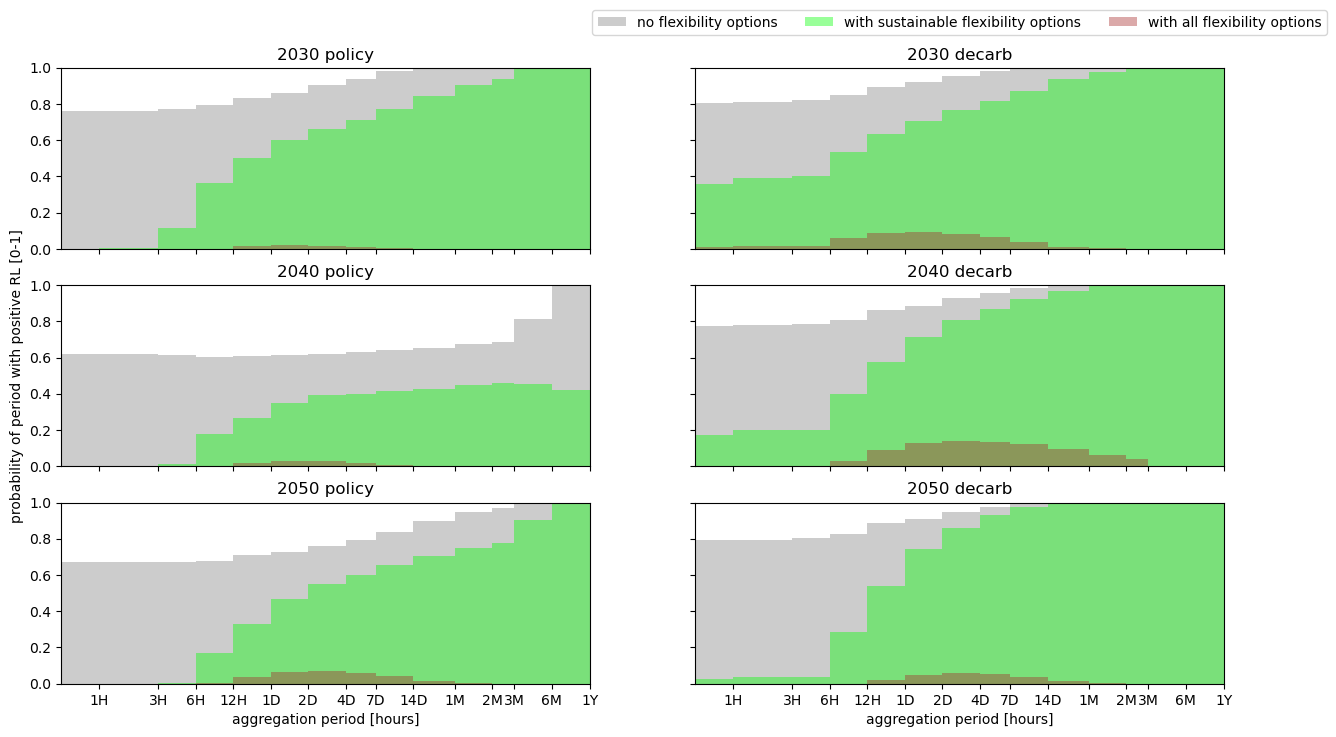

In [209]:
fig,axes = plt.subplots(ncols=2, nrows=3, figsize=(15,8), sharey=True, sharex=True)
for r,infrastructure_year in enumerate([2030,2040,2050]):
    for c,infrastructure_scenario in enumerate(['policy', 'decarb']):
        ax = axes[r,c]
        ax.set_xscale('log')
        ax.set_xlim(0.5,period_lengths[-1])
        ax.set_ylim(0,1)
        ax.set_xticks(period_lengths)
        ax.set_xticklabels(period_length_labels)
        ax.set_title(f"{infrastructure_year} {infrastructure_scenario}")
        if r == 2:
            ax.set_xlabel('aggregation period [hours]')
        plt.minorticks_off()

        X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)
        flex = get_flex_power(infrastructure_scenario, infrastructure_year, period_lengths)
        sustainable_flex_option_names = [f for f in flex_option_names if 'Gas' not in f]
        flex_sustainable = flex.loc[sustainable_flex_option_names]

        prob_above = (X > 0).sum(('weather_year', 'start_time')) / (X.shape[1] * X.shape[2])
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
            ax.fill_between([start_x,period_length], [prob_above.loc[period_length]] * 2, [0] * 2, facecolor='gray', edgecolor='none', alpha=0.4)
        ax.fill_between([], [], [], facecolor='gray', edgecolor='none', alpha=0.4, label='no flexibility options')
        prob_above = (X - flex_sustainable.sum('name') > 0).sum(('weather_year', 'start_time')) / (X.shape[1] * X.shape[2])
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
            ax.fill_between([start_x,period_length], [prob_above.loc[period_length]] * 2, [0] * 2, facecolor='lime', edgecolor='none', alpha=0.4)
        ax.fill_between([], [], [], facecolor='lime', edgecolor='none', alpha=0.4, label='with sustainable flexibility options')
        prob_above = (X - flex.sum('name') > 0).sum(('weather_year', 'start_time')) / (X.shape[1] * X.shape[2])
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
            ax.fill_between([start_x,period_length], [prob_above.loc[period_length]] * 2, [0] * 2, facecolor='brown', edgecolor='none', alpha=0.4)
        ax.fill_between([], [], [], facecolor='brown', edgecolor='none', alpha=0.4, label='with all flexibility options')
    
        if c == 0 and r==1:
            ax.set_ylabel('probability of period with positive RL [0-1]')
        
        if r == 0 and c == 1:
            ax.legend(bbox_to_anchor=(0.5,1.25), ncols=3, loc='center')
plt.savefig(f'../plots/RL/RL_prob_positive_all.png', dpi=300)

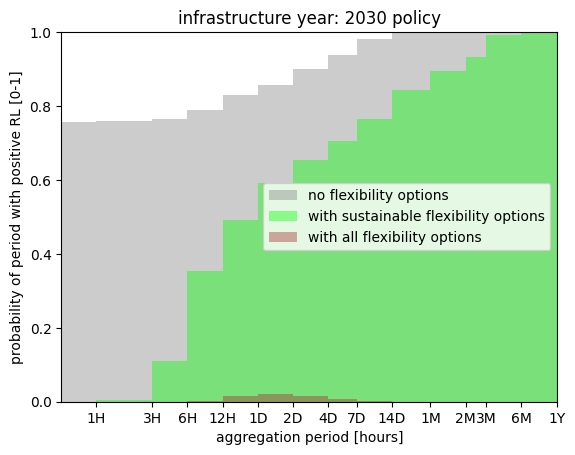

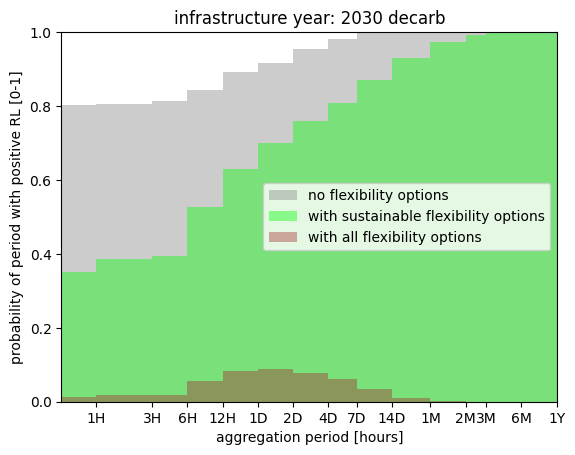

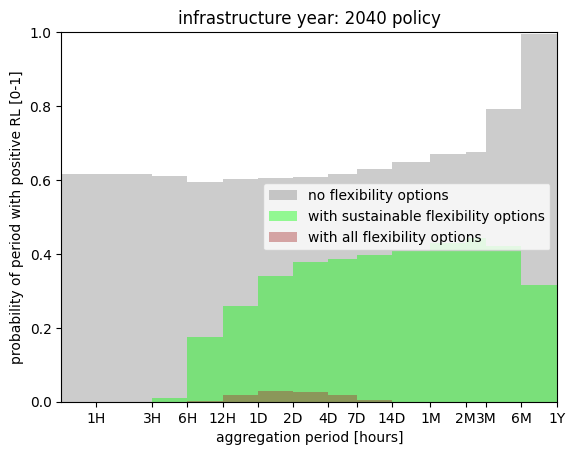

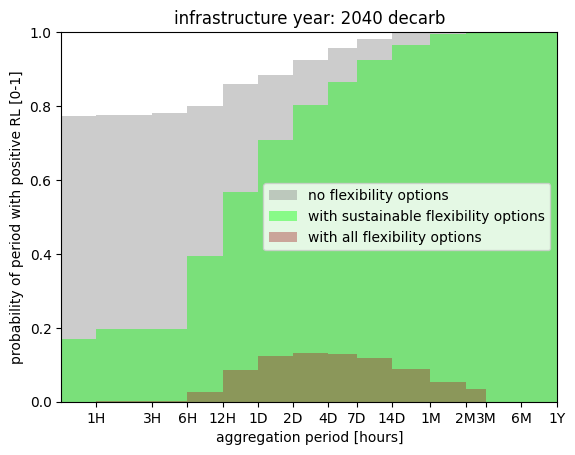

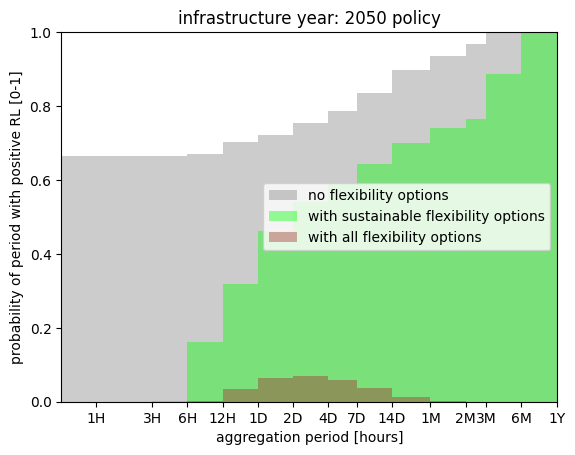

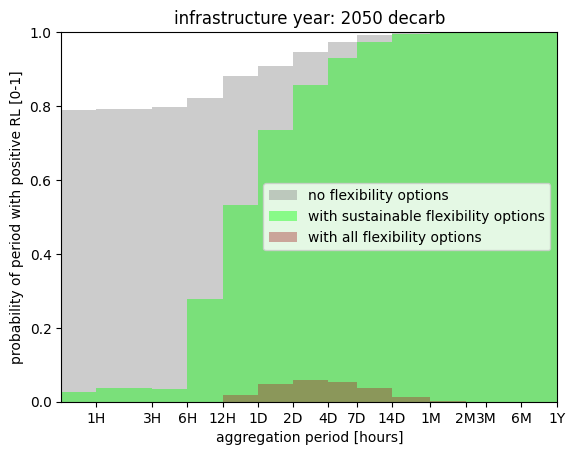

In [ ]:
for infrastructure_year in [2030,2040,2050]:
    for infrastructure_scenario in ['policy', 'decarb']:
        X = get_rl(infrastructure_scenario, infrastructure_year, period_lengths)
        flex = get_flex_power(infrastructure_scenario, infrastructure_year, period_lengths)
        sustainable_flex_option_names = [f for f in flex_option_names if 'Gas' not in f]
        flex_sustainable = flex.loc[sustainable_flex_option_names]

        ax = prepare_axes()
        prob_above = (X > 0).sum(('weather_year', 'start_time')) / (X.shape[1] * X.shape[2])
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
            ax.fill_between([start_x,period_length], [prob_above.loc[period_length]] * 2, [0] * 2, facecolor='gray', edgecolor='none', alpha=0.4)
        ax.fill_between([], [], [], facecolor='gray', edgecolor='none', alpha=0.4, label='no flexibility options')
        prob_above = (X - flex_sustainable.sum('name') > 0).sum(('weather_year', 'start_time')) / (X.shape[1] * X.shape[2])
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
            ax.fill_between([start_x,period_length], [prob_above.loc[period_length]] * 2, [0] * 2, facecolor='lime', edgecolor='none', alpha=0.4)
        ax.fill_between([], [], [], facecolor='lime', edgecolor='none', alpha=0.4, label='with sustainable flexibility options')
        prob_above = (X - flex.sum('name') > 0).sum(('weather_year', 'start_time')) / (X.shape[1] * X.shape[2])
        for period_length, start_x in zip(X.period_length.values, [0.5]+list(X.period_length.values[:-1])):
            ax.fill_between([start_x,period_length], [prob_above.loc[period_length]] * 2, [0] * 2, facecolor='brown', edgecolor='none', alpha=0.4)
        ax.fill_between([], [], [], facecolor='brown', edgecolor='none', alpha=0.4, label='with all flexibility options')
        ax.set_ylabel('probability of period with positive RL [0-1]')
        ax.set_ylim(0,1)
        ax.set_title(f"infrastructure year: {infrastructure_year} {infrastructure_scenario}")
        ax.legend(loc='center right')
        plt.savefig(f'../plots/RL/RL_prob_positive_{infrastructure_scenario}_{infrastructure_year}.png', dpi=300)

### RE

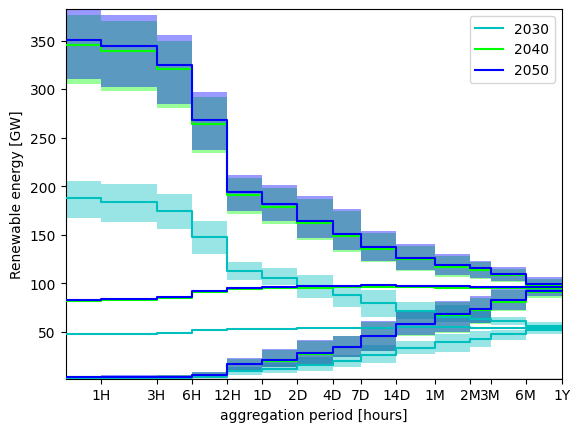

In [ ]:
ax = prepare_axes()
for infrastructure_year,color in [
    (2030, 'c'),
    (2040, 'lime'),
    (2050, 'b')
    ]:
    X = get_re(infrastructure_scenario, infrastructure_year, period_lengths)
    ax = plot_fish(ax, X, color=color, plot_year_stripes=False)
    ax.plot([], [], color=color, label=infrastructure_year)

ax.set_ylabel('Renewable energy [GW]')
ax.legend()
plt.savefig(f'../plots/RE/RE_all.png', dpi=300)

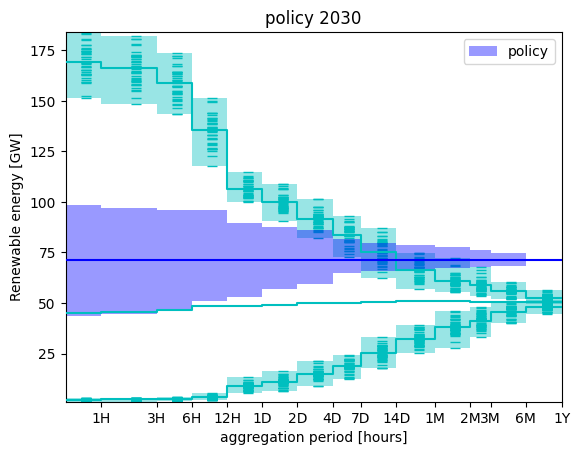

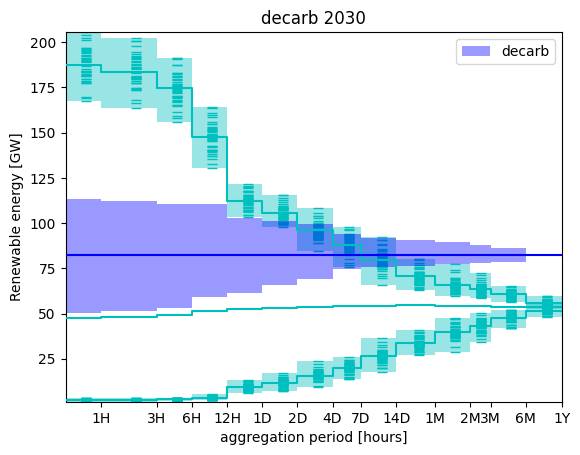

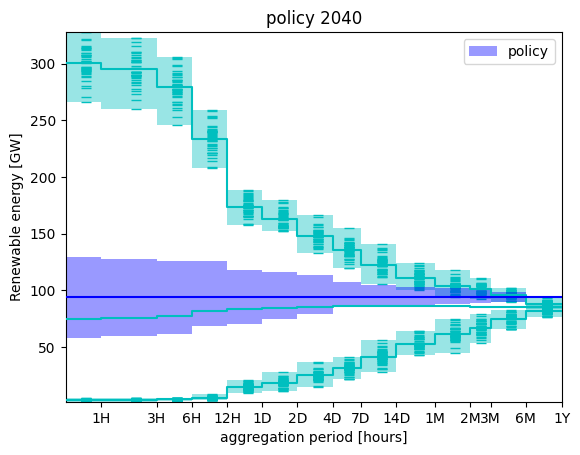

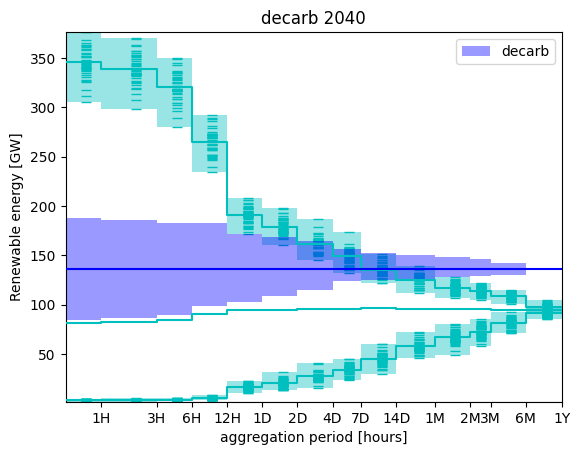

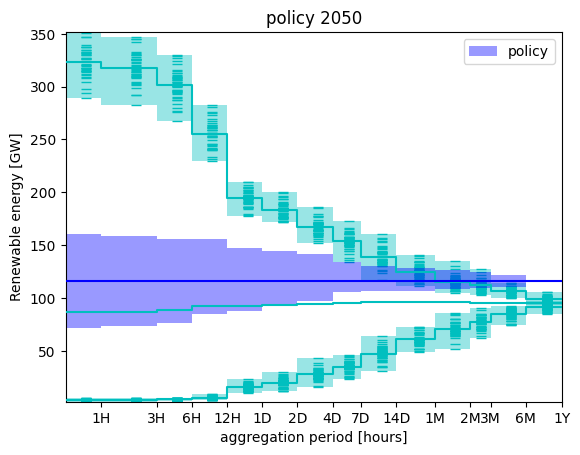

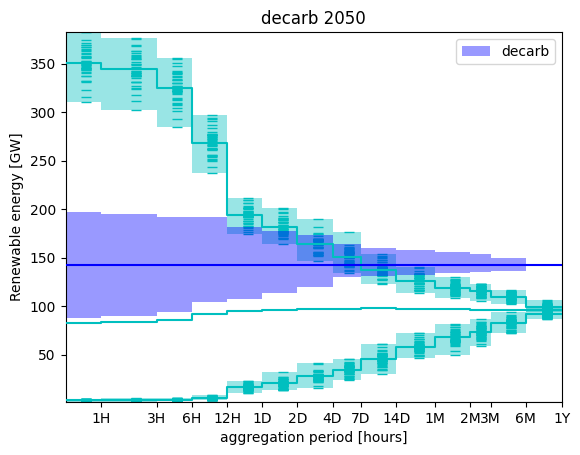

In [ ]:
for infrastructure_year in [2030,2040,2050]:
    for infrastructure_scenario in ['policy','decarb']:
        X = get_re(infrastructure_scenario, infrastructure_year, period_lengths)
        ax = prepare_axes()
        ax.set_title(f"{infrastructure_scenario} {infrastructure_year}")
        ax = plot_fish(ax, X, color='c')
        ax = plot_load(ax, infrastructure_scenario, infrastructure_year, period_lengths, color)
        ax.set_ylabel('Renewable energy [GW]')
        ax.legend()
        plt.savefig(f'../plots/RE/{infrastructure_scenario}_{infrastructure_year}.png', dpi=300)

In [ ]:
def plot_seasonal_occurence(infrastructure_year, demand_scenario, period_lengths, period_length_labels, colors):
    load = demand[f'Electricity demand {infrastructure_year}{demand_scenario}']
    load = np.append(load[:8760], load[:8760])

    # create output array to store the aggregated data
    out = xr.DataArray(
        dims=['period_length', 'weather_year', 'start_time'], 
        coords=dict(
            # all hours of the year
            start_time=range(365*24), 
            # all available weather years
            weather_year=range(1980,2022,1),
            # periods over which to aggregate
            period_length=period_lengths
        )
    )

    # go through weather years
    for weather_year in out.weather_year.values:
        re = rn.estimate_renewable_energy_generation(weather_year=weather_year, infrastructure_scenario=demand_scenario, infrastructure_year=infrastructure_year) 
        re_next = rn.estimate_renewable_energy_generation(
            weather_year=weather_year + 1, infrastructure_scenario=demand_scenario, infrastructure_year=infrastructure_year)
        re = np.append(re[:8760], re_next[:8760])
        rl = xr.DataArray(load - re, dims=["time"], coords=dict(time=np.arange(0,24*365*2,1,'int')))
        for period_length in out.period_length.values:
            # store average or aggregated time windows
            out.loc[period_length,weather_year] = rl.rolling(time=period_length).mean()[period_length-1:][:365*24].values


    fig,axes = plt.subplots(nrows=2, figsize=(6,6), gridspec_kw=dict(height_ratios=[1,1]), sharex=True)

    x_,y_ = [],[]

    # identify extremes for all period_length length and weather years
    mini = out.min('start_time')
    maxi = out.max('start_time')

    # got through period_lengths
    for period_length, start_x in zip(out.period_length.values, [0.5]+list(out.period_length.values[:-1])):
        # do for minimums and maximums
        for stat_name, statistic in zip(['min','max'],[mini,maxi]):
            # fill between lowest and highest weather year

            start_time = out.loc[period_length].argmax('start_time')
            seas = start_time.copy()
            seas[start_time <= (datetime.datetime(2025,3,1).timetuple().tm_yday -1)*24] = 0
            seas[start_time > (datetime.datetime(2025,12,1).timetuple().tm_yday -1)*24] = 0
            seas[(start_time > (datetime.datetime(2025,3,1).timetuple().tm_yday -1)*24) & (start_time <= (datetime.datetime(2025,6,1).timetuple().tm_yday -1)*24)] = 1
            seas[(start_time > (datetime.datetime(2025,6,1).timetuple().tm_yday -1)*24) & (start_time <= (datetime.datetime(2025,9,1).timetuple().tm_yday -1)*24)] = 2
            seas[(start_time > (datetime.datetime(2025,9,1).timetuple().tm_yday -1)*24) & (start_time <= (datetime.datetime(2025,12,1).timetuple().tm_yday -1)*24)] = 3

            y = 0
            for s,color in zip(range(4), colors):
                axes[0].fill_between(
                    [start_x,period_length], 
                    [y] * 2, 
                    [y + np.sum(seas == s)] * 2,
                    color=color)
                y += np.sum(seas == s)

            start_time = out.loc[period_length].argmin('start_time')
            seas = start_time.copy()
            seas[start_time <= (datetime.datetime(2025,3,1).timetuple().tm_yday -1)*24] = 0
            seas[start_time > (datetime.datetime(2025,12,1).timetuple().tm_yday -1)*24] = 0
            seas[(start_time > (datetime.datetime(2025,3,1).timetuple().tm_yday -1)*24) & (start_time <= (datetime.datetime(2025,6,1).timetuple().tm_yday -1)*24)] = 1
            seas[(start_time > (datetime.datetime(2025,6,1).timetuple().tm_yday -1)*24) & (start_time <= (datetime.datetime(2025,9,1).timetuple().tm_yday -1)*24)] = 2
            seas[(start_time > (datetime.datetime(2025,9,1).timetuple().tm_yday -1)*24) & (start_time <= (datetime.datetime(2025,12,1).timetuple().tm_yday -1)*24)] = 3

            y = 0
            for s,color in zip(range(4), colors):
                axes[1].fill_between(
                    [start_x,period_length], 
                    [y] * 2, 
                    [y + np.sum(seas == s)] * 2,
                    color=color)
                y += np.sum(seas == s)

    axes[0].set_title(f"infrastructure year: {infrastructure_year} {demand_scenario}")
    axes[1].set_xscale('log')
    axes[1].set_xticks(period_lengths)
    axes[1].set_xticklabels(period_length_labels)
    axes[0].set_yticks([])
    axes[1].set_yticks([])
    axes[1].set_xlabel('aggregation period [hours]')
    plt.minorticks_off()
    plt.tight_layout()

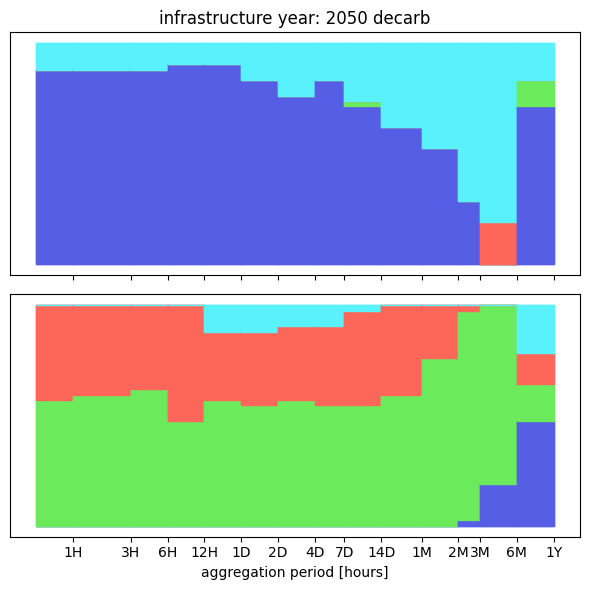

In [ ]:
season_colors = distinctipy.get_colors(4, pastel_factor=0.5)
plot_seasonal_occurence(infrastructure_year, infrastructure_scenario, period_lengths, period_length_labels, colors=season_colors)

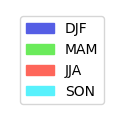

In [ ]:
fig,ax = plt.subplots(figsize=(1.3,1))
for season,color in zip(['DJF', 'MAM', 'JJA', 'SON'], season_colors):
    ax.fill_between([],[],[], color=color, label=season)
ax.legend()
_ = ax.axis('off')

# Evaluation

## Capacity factors

### PV

In [179]:
test_year = 2020

In [180]:
cap_DEU_future = rn._cap_future[f"cap_pv_ger{2030}-policy"].values
cap = xr.DataArray(dims=['time','region'], coords=dict(time=np.arange(0,8760,1,'int'), region=rn._cap_pv_ratio.index))
for region in cap.region.values:
    cap.loc[:,region] = cap_DEU_future * rn._cap_pv_ratio.loc[region]
cf_pred = rn._estimator_pv.predict(test_year, cap)[0]

In [181]:
cf_obs = df.loc[df.year==test_year, 'cf_pv'].values

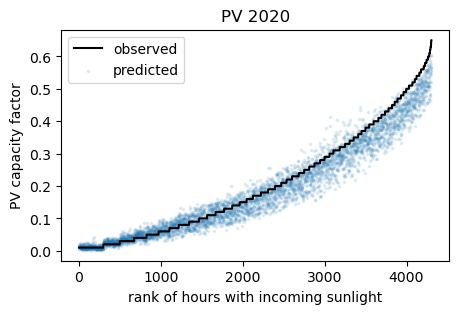

In [182]:
fig,ax = plt.subplots(figsize=(5,3))
rank = np.argsort(cf_obs)
rank = rank[np.where(cf_obs[rank] > 0)[0][0]:]
ax.plot(np.arange(rank.shape[0]), cf_obs[rank], color='k', label='observed')
ax.scatter(np.arange(rank.shape[0]), cf_pred[rank], marker='.', s=10, alpha=0.1, label='predicted')
#sns.kdeplot(x=np.arange(rank.shape[0]), y=cf_pred[rank], ax=ax, label='predicted')
ax.set_xlabel('rank of hours with incoming sunlight')
ax.set_ylabel('PV capacity factor')
ax.set_title(f'PV {test_year}')
ax.legend()

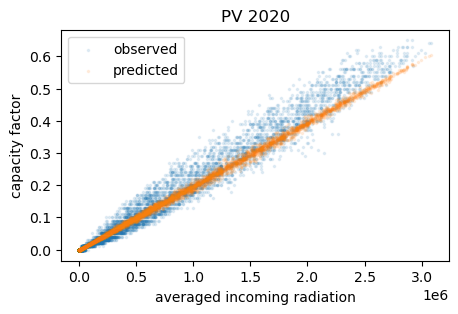

In [183]:
fig,ax = plt.subplots(figsize=(5,3))
ax.scatter(radiation.loc[str(test_year),'DEU'], cf_obs, marker='.', s=10, alpha=0.1, label='observed')
ax.scatter(radiation.loc[str(test_year),'DEU'], cf_pred, marker='.', s=10, alpha=0.1, label='predicted')
ax.set_xlabel('averaged incoming radiation')
ax.set_ylabel('capacity factor')
ax.set_title(f'PV {test_year}')
ax.legend()

### wind onshore

In [173]:
test_year = 2020

In [174]:
cap_DEU_future = rn._cap_future[f"cap_wion_ger{2030}-policy"].values
cap = xr.DataArray(dims=['time','region'], coords=dict(time=np.arange(0,8760,1,'int'), region=rn._cap_pv_ratio.index))
for region in cap.region.values:
    cap.loc[:,region] = cap_DEU_future * rn._cap_pv_ratio.loc[region]
cf_pred = rn._estimator_wind_on.predict(test_year, cap)[0]

In [175]:
cf_obs = df.loc[df.year==test_year, 'cf_wion'].values

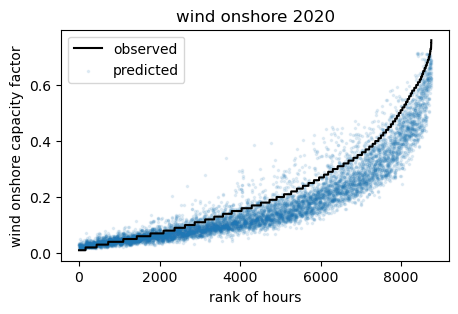

In [176]:
fig,ax = plt.subplots(figsize=(5,3))
rank = np.argsort(cf_obs)
rank = rank[np.where(cf_obs[rank] > 0)[0][0]:]
ax.plot(np.arange(rank.shape[0]), cf_obs[rank], color='k', label='observed')
ax.scatter(np.arange(rank.shape[0]), cf_pred[rank], marker='.', s=10, alpha=0.1, label='predicted')
#sns.kdeplot(x=np.arange(rank.shape[0]), y=cf_pred[rank], ax=ax, label='predicted')
ax.set_xlabel('rank of hours')
ax.set_ylabel('wind onshore capacity factor')
ax.set_title(f'wind onshore {test_year}')
ax.legend()

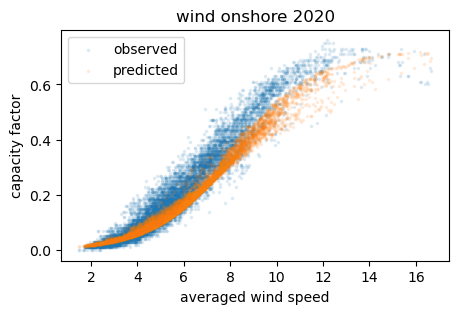

In [177]:
fig,ax = plt.subplots(figsize=(5,3))
ax.scatter(wind.loc[str(test_year),'DEU'], cf_obs, marker='.', s=10, alpha=0.1, label='observed')
ax.scatter(wind.loc[str(test_year),'DEU'], cf_pred, marker='.', s=10, alpha=0.1, label='predicted')
ax.set_xlabel('averaged wind speed')
ax.set_ylabel('capacity factor')
ax.set_title(f'wind onshore {test_year}')
ax.legend()

## Example sensitivity

In [ ]:
"""
Example sensitivity analysis (deactivated - legacy code)
rn = renewable(df)
rn.add_installed_capacity(capacity)
for training_years in [[2021,2022,2023], [2018,2019,2020]]:
    rn.filter_training_data(training_years)
    rn.PV_cf_training()
    rn.wind_on_cf_training(wind_sigmoid)
    rn.wind_of_cf_training(wind_sigmoid)
    y = rn.estimate_renewable_energy_generation(weather_year=1963, infrastructure_year=2020)[:1000]
    plt.plot(y, label=f"training years: {','.join([str(year) for year in training_years])}")
plt.legend()
"""

'\nExample sensitivity analysis (deactivated - legacy code)\nrn = renewable(df)\nrn.add_installed_capacity(capacity)\nfor training_years in [[2021,2022,2023], [2018,2019,2020]]:\n    rn.filter_training_data(training_years)\n    rn.PV_cf_training()\n    rn.wind_on_cf_training(wind_sigmoid)\n    rn.wind_of_cf_training(wind_sigmoid)\n    y = rn.estimate_renewable_energy_generation(weather_year=1963, infrastructure_year=2020)[:1000]\n    plt.plot(y, label=f"training years: {\',\'.join([str(year) for year in training_years])}")\nplt.legend()\n'